In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt


def create_balanced_dataset(df):
    num_spam = df[df["label"]=="spam"].shape[0]
    ham_subset = df[df["label"]=="ham"].sample(num_spam, random_state=43)
    balanced_df = pd.concat([ham_subset, df[df["label"]=="spam"]])
    return balanced_df


def random_split(df, train_frac, val_frac, random_state=42):
    # frac=1，打乱所有行， reset_index(drop=True)重置索引，true表示丢弃旧索引
    df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    total_len = len(df)
    train_end = int(train_frac * total_len)
    val_end = train_end + int(val_frac * total_len)
    train_df = df[:train_end]
    val_df = df[train_end:val_end]
    test_df = df[val_end:]
    return train_df, val_df, test_df


# ============ Dataset 类 ============

class SpamDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=None, padding_token=50256):
        self.encoded_text = df["Text"].apply(lambda x: tokenizer.encode(x)).values
        self.labels = df["label"].values
        if max_length is None:
            max_length = max(len(tokens) for tokens in self.encoded_text)
        self.max_length = max_length
        self.encoded_text = [t[:max_length] for t in self.encoded_text]
        self.encoded_text = [tokens + [padding_token] * (max_length - len(tokens)) for tokens in self.encoded_text]
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return torch.tensor(self.encoded_text[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)


# ============ GPT 模型相关类 ============

class LayerNorm(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.shift = nn.Parameter(torch.zeros(cfg["hidden_size"]))
        self.scale = nn.Parameter(torch.ones(cfg["hidden_size"]))
        self.eps = 1e-5
    
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        normalized_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * normalized_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2/torch.pi)) * (x + 0.044715 * torch.pow(x, 3))
            ))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(cfg["hidden_size"], 4*cfg["hidden_size"]),
            GELU(),
            nn.Linear(4*cfg["hidden_size"], cfg["hidden_size"])
        )
    def forward(self, x):
        return self.fc(x)


class MultiHeadAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.head_dim = cfg["hidden_size"] // cfg["num_heads"]
        self.num_heads = cfg["num_heads"]
        self.w_q = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.w_k = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.w_v = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.w_o = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.dropout = nn.Dropout(cfg["drop_rate"])
        self.register_buffer("mask",
                torch.triu(torch.ones(cfg["context_size"], cfg["context_size"]), diagonal=1).bool()
        )
    
    def forward(self, x):
        b, t, c = x.size()
        q = self.w_q(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.w_k(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.w_v(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        attn_scores = (q @ k.transpose(-2, -1)) / torch.sqrt(torch.tensor(self.head_dim, dtype=torch.float32))
        attn_scores = attn_scores.masked_fill(self.mask[:t, :t], float('-inf'))
        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        attn_output = attn_weights @ v
        attn_output = attn_output.transpose(1, 2).contiguous().view(b, t, c)
        return self.w_o(attn_output)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.norm1 = LayerNorm(cfg)
        self.norm2 = LayerNorm(cfg)
        self.attn = MultiHeadAttention(cfg)
        self.dropout = nn.Dropout(cfg["drop_rate"])
        self.ffn = FeedForward(cfg)
    
    def forward(self, x):
        short_cut = x
        x = self.norm1(x)
        x = self.attn(x)
        x = self.dropout(x)
        x = x + short_cut

        short_cut = x
        x = self.norm2(x)
        x = self.ffn(x)
        x = self.dropout(x)
        x = x + short_cut
        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.embedding = nn.Embedding(cfg["vocab_size"], cfg["hidden_size"])
        self.pos_emb = nn.Embedding(cfg["context_size"], cfg["hidden_size"])
        self.drop = nn.Dropout(cfg["drop_rate"])
        self.blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["num_layers"])]
        )
        self.final_norm = LayerNorm(cfg)
        self.out_head = nn.Linear(cfg["hidden_size"], cfg["vocab_size"], bias=False)
    
    def forward(self, idx):
        b, t = idx.size()
        token_emb = self.embedding(idx)  
        pos_emb = self.pos_emb(torch.arange(t, device=idx.device))  # (t, hidden_size)
        x = self.drop(token_emb + pos_emb) 
        x = self.blocks(x)  
        x = self.final_norm(x) 
        return self.out_head(x) 


# ============ 生成与工具函数 ============

def generate(model, idx, max_new_tokens, context_size, temperature=0.0, topk=None):
    is_training = model.training
    model.eval()
    for _ in range(max_new_tokens):
        idx_used = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_used)[:, -1, :]
        if topk is not None:
            topk_logits, _ = torch.topk(logits, topk)
            logits = torch.where(
                condition=logits < topk_logits[..., [-1]],
                input=torch.tensor(float('-inf')),
                other=logits
            )
        if temperature > 0.0:
            logits = logits / temperature
            next_token = torch.multinomial(torch.softmax(logits, dim=-1), num_samples=1)
            idx = torch.cat([idx, next_token], dim=1)
        else:
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
            idx = torch.cat([idx, next_token], dim=1)
    if is_training:
        model.train()
    return idx


def tokens_to_text(tokens, tokenizer):
    tokens = tokens.squeeze(0).tolist()  # 移除batch维度并转换为列表
    return tokenizer.decode(tokens)


def text_to_tokens(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    return torch.tensor(encoded, dtype=torch.long).unsqueeze(0) # 添加batch维度


# ============ 训练与评估函数 ============

def calculate_acc(data_loader, model, device,num_batches=None):
    is_training = model.training
    model.eval()
    correct, total = 0, 0
    num_batches = min(num_batches, len(data_loader)) if num_batches is not None else len(data_loader)
    for i, (inputs, labels) in enumerate(data_loader):
        if i >= num_batches:
            break
        inputs, labels = inputs.to(device), labels.to(device)
        with torch.no_grad():
            outputs = model(inputs)[:, -1, :]
            predictions = torch.argmax(outputs, dim=-1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    accuracy = correct / total if total > 0 else 0
    model.train(is_training)
    return accuracy


def calculate_loss_single_batch(inputs, targets, model, device):
    criterion = nn.CrossEntropyLoss()
    inputs, targets = inputs.to(device), targets.to(device)
    outputs = model(inputs)[:, -1, :]
    loss = criterion(outputs, targets)
    return loss


def calculate_loss(data_loader, model, device, num_batches=None):
    total_loss = 0.0
    num_batches = min(num_batches, len(data_loader)) if num_batches is not None else len(data_loader)
    for i, (inputs, labels) in enumerate(data_loader):
        if i >= num_batches:
            break
        with torch.no_grad():
            loss = calculate_loss_single_batch(inputs, labels, model, device)
        total_loss += loss.item()
    average_loss = total_loss / num_batches if num_batches > 0 else 0
    return average_loss


def train_loader_f(train_loader, val_loader, model, optimizer, device, num_epochs, val_freq):
    train_losses, val_losses, train_accs, val_accs, tokens_seen = [], [], [], [], []
    for epoch in range(num_epochs):
        model.train()
        for i, (inputs, labels) in enumerate(train_loader):
            optimizer.zero_grad()
            loss = calculate_loss_single_batch(inputs, labels, model, device)
            loss.backward()
            optimizer.step()
        if epoch % val_freq == 0:
            train_loss = calculate_loss(train_loader, model, device)
            val_loss = calculate_loss(val_loader, model, device)
            train_acc = calculate_acc(train_loader, model, device)
            val_acc = calculate_acc(val_loader, model, device)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)
            tokens_seen.append((epoch + 1) * len(train_loader.dataset))
            print(f"Epoch {epoch+1}/{num_epochs} - "
                  f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
                  f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
    return train_losses, val_losses, train_accs, val_accs, tokens_seen


# ============ 绘图函数 ============

def plot_values(epochs_seen, examples_seen, train_values, val_values, label='loss'):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_values, label=f'Train {label}')
    ax1.plot(epochs_seen, val_values, label=f'Val {label}', linestyle='-.')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel(label)
    ax1.legend(loc='best')
    
    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel('Examples Seen')
    plt.title(f'Train and Val {label} vs Epochs and Examples Seen')
    plt.show()


# ============ 分类函数 ============

def email_classifier(model, text, tokenizer, device,max_length):
    idx = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    idx = idx[:max_length]
    idx = idx + [50256] * (max_length - len(idx))
    idx = torch.tensor(idx, dtype=torch.long).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(idx)[:, -1, :]
        prediction = torch.argmax(output, dim=-1).item()
    return prediction


# ============ 配置 ============

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_size": 1024,
    "num_layers": 12,
    "num_heads": 12,
    "hidden_size": 768,
    "drop_rate": 0.1,
    "qkv_bias": True,
}

In [4]:
def get_model(cfg, device, file_path, grid_allowed_modules):
    model = GPTModel(cfg)
    model.load_state_dict(torch.load(file_path))
    for param in model.parameters():
        param.requires_grad = False
    model.out_head = nn.Linear(cfg["hidden_size"], 2, bias=False)
    try:
        for module_name in grid_allowed_modules:
            for param in eval(f"model.{module_name}").parameters():
                param.requires_grad = True
            print(f"Unfrozen module: {module_name}")
    except Exception as e:
        print(f"Error freezing modules: {e}")
        raise e
    model.to(device)
    return model


In [11]:
data_file_path = "E:\AI_projects\LLMs\LLMs-from-scratch-mine\chapter6\sms_spam_collection\SMSSpamCollection.tsv"
df = pd.read_csv(data_file_path, sep="\t", header=None, names=["label", "Text"])
print(df.head())

  label                                               Text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [12]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
balanced_df = create_balanced_dataset(df)
balanced_df["label"] = balanced_df["label"].map({"ham": 0, "spam": 1})
train_df, val_df, test_df = random_split(balanced_df, train_frac=0.7, val_frac=0.1, random_state=42)
print(f"Train size: {len(train_df)}, Val size: {len(val_df)}, Test size: {len(test_df)}")

train_dataset = SpamDataset(train_df, tokenizer)
max_length = train_dataset.max_length
val_dataset = SpamDataset(val_df, tokenizer, max_length=max_length)
test_dataset = SpamDataset(test_df, tokenizer, max_length=max_length)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, drop_last=False)

Train size: 1045, Val size: 149, Test size: 300


In [13]:
for inputs, labels in train_loader:
    print("Input:", inputs)
    print("Labels:", labels)
    break

Input: tensor([[17250, 42666,   663,  ..., 50256, 50256, 50256],
        [ 5492,   869,   674,  ..., 50256, 50256, 50256],
        [24446,  3857,   284,  ..., 50256, 50256, 50256],
        ...,
        [10002,   355,   867,  ..., 50256, 50256, 50256],
        [   40,   760,   345,  ..., 50256, 50256, 50256],
        [   32,  7501,   477,  ..., 50256, 50256, 50256]])
Labels: tensor([1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0])


## 仅out_head

C:\Users\86178\AppData\Local\Temp\ipykernel_20268\2615074366.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(file_path))


Unfrozen module: out_head
Initial Train Loss: 0.8504, Initial Val Loss: 0.7986
Epoch 1/5 - Train Loss: 0.9095, Val Loss: 0.8824, Train Acc: 0.4865, Val Acc: 0.5168
Epoch 2/5 - Train Loss: 0.8660, Val Loss: 0.7882, Train Acc: 0.3971, Val Acc: 0.3691
Epoch 3/5 - Train Loss: 0.8919, Val Loss: 0.8236, Train Acc: 0.5163, Val Acc: 0.4832
Epoch 4/5 - Train Loss: 0.8858, Val Loss: 0.8606, Train Acc: 0.5154, Val Acc: 0.4832
Epoch 5/5 - Train Loss: 0.8297, Val Loss: 0.9784, Train Acc: 0.5135, Val Acc: 0.4832


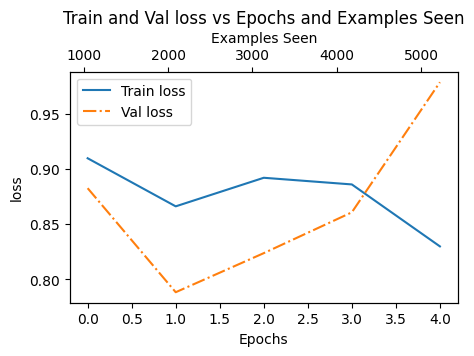

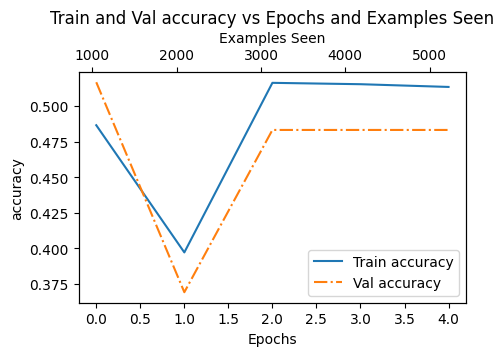

In [ ]:
allowed_modules = ["out_head"]
file_path = "E:\AI_projects\LLMs\LLMs-from-scratch-mine\chapter5\gpt_124M_weights.pth"
model1 = get_model(GPT_CONFIG_124M, device="cuda", file_path=file_path, grid_allowed_modules=allowed_modules)
optimizer = torch.optim.AdamW(model1.parameters(), lr=1e-5, weight_decay=0.01)
model1.eval()
t_loss, val_loss = calculate_loss(train_loader, model1, device="cuda", num_batches=10), calculate_loss(val_loader, model1, device="cuda", num_batches=10)
print(f"Initial Train Loss: {t_loss:.4f}, Initial Val Loss: {val_loss:.4f}")

num_epochs = 5
val_freq = 1

train_losses, val_losses, train_accs, val_accs, examples_seen = train_loader_f(train_loader, val_loader, model1, optimizer, device="cuda", num_epochs=num_epochs, val_freq=val_freq)

plot_values(list(range(0, num_epochs, val_freq)), examples_seen, train_losses, val_losses, label='loss')
plot_values(list(range(0, num_epochs, val_freq)), examples_seen, train_accs, val_accs, label='accuracy')

C:\Users\86178\AppData\Local\Temp\ipykernel_20268\2615074366.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(file_path))


Unfrozen module: out_head
Initial Train Loss: 3.3492, Initial Val Loss: 3.0275
Epoch 1/8 - Train Loss: 2.4520, Val Loss: 2.3145, Train Acc: 0.4846, Val Acc: 0.5168
Epoch 2/8 - Train Loss: 1.7546, Val Loss: 1.7812, Train Acc: 0.4846, Val Acc: 0.5168
Epoch 3/8 - Train Loss: 1.2737, Val Loss: 1.2374, Train Acc: 0.4837, Val Acc: 0.5168
Epoch 4/8 - Train Loss: 0.9934, Val Loss: 0.8964, Train Acc: 0.4875, Val Acc: 0.5168
Epoch 5/8 - Train Loss: 0.9095, Val Loss: 0.9180, Train Acc: 0.4538, Val Acc: 0.4899
Epoch 6/8 - Train Loss: 0.8535, Val Loss: 0.8406, Train Acc: 0.5058, Val Acc: 0.4564
Epoch 7/8 - Train Loss: 0.8293, Val Loss: 0.7698, Train Acc: 0.5154, Val Acc: 0.4832
Epoch 8/8 - Train Loss: 0.8116, Val Loss: 0.8646, Train Acc: 0.5154, Val Acc: 0.4832


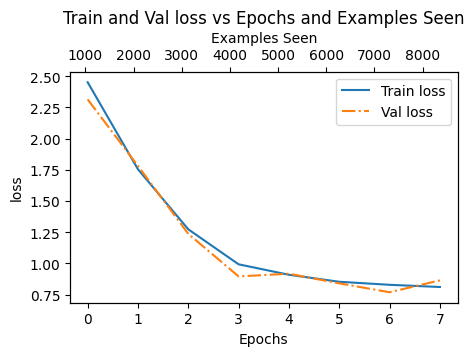

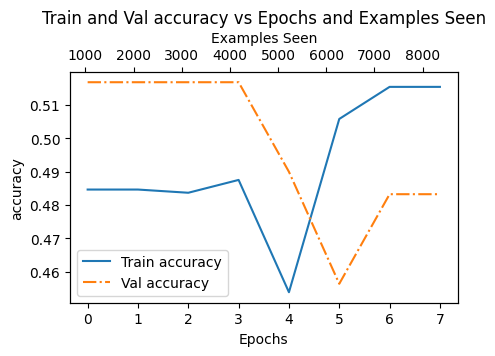

In [15]:
allowed_modules = ["out_head"]
file_path = "E:\AI_projects\LLMs\LLMs-from-scratch-mine\chapter5\gpt_124M_weights.pth"
model12 = get_model(GPT_CONFIG_124M, device="cuda", file_path=file_path, grid_allowed_modules=allowed_modules)
optimizer = torch.optim.AdamW(model12.parameters(), lr=2e-5, weight_decay=0.01)
model12.eval()
t_loss, val_loss = calculate_loss(train_loader, model12, device="cuda", num_batches=10), calculate_loss(val_loader, model12, device="cuda", num_batches=10)
print(f"Initial Train Loss: {t_loss:.4f}, Initial Val Loss: {val_loss:.4f}")

num_epochs = 8
val_freq = 1

train_losses, val_losses, train_accs, val_accs, examples_seen = train_loader_f(train_loader, val_loader, model12, optimizer, device="cuda", num_epochs=num_epochs, val_freq=val_freq)

plot_values(list(range(0, num_epochs, val_freq)), examples_seen, train_losses, val_losses, label='loss')
plot_values(list(range(0, num_epochs, val_freq)), examples_seen, train_accs, val_accs, label='accuracy')

C:\Users\86178\AppData\Local\Temp\ipykernel_20268\2615074366.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(file_path))


Unfrozen module: out_head
Initial Train Loss: 1.6805, Initial Val Loss: 1.6106
Epoch 1/8 - Train Loss: 0.8570, Val Loss: 0.9361, Train Acc: 0.5163, Val Acc: 0.4832
Epoch 2/8 - Train Loss: 0.8547, Val Loss: 0.8029, Train Acc: 0.5135, Val Acc: 0.4832
Epoch 3/8 - Train Loss: 0.9031, Val Loss: 0.8406, Train Acc: 0.5154, Val Acc: 0.4832
Epoch 4/8 - Train Loss: 0.8595, Val Loss: 0.8080, Train Acc: 0.5154, Val Acc: 0.4832
Epoch 5/8 - Train Loss: 0.8749, Val Loss: 0.7937, Train Acc: 0.5154, Val Acc: 0.4832
Epoch 6/8 - Train Loss: 0.8821, Val Loss: 0.8669, Train Acc: 0.5154, Val Acc: 0.4832
Epoch 7/8 - Train Loss: 0.9109, Val Loss: 0.7997, Train Acc: 0.5154, Val Acc: 0.4832
Epoch 8/8 - Train Loss: 0.8185, Val Loss: 0.9015, Train Acc: 0.5154, Val Acc: 0.4832


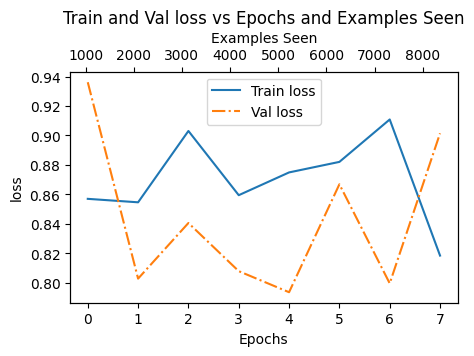

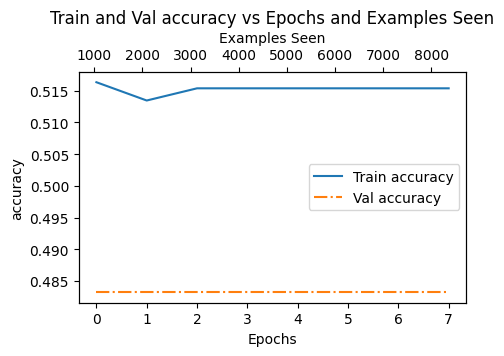

In [21]:
allowed_modules = ["out_head"]
file_path = "E:\AI_projects\LLMs\LLMs-from-scratch-mine\chapter5\gpt_124M_weights.pth"
model13 = get_model(GPT_CONFIG_124M, device="cuda", file_path=file_path, grid_allowed_modules=allowed_modules)
optimizer = torch.optim.AdamW(model13.parameters(), lr=5e-5, weight_decay=0.1)
model13.eval()
t_loss, val_loss = calculate_loss(train_loader, model13, device="cuda", num_batches=10), calculate_loss(val_loader, model13, device="cuda", num_batches=10)
print(f"Initial Train Loss: {t_loss:.4f}, Initial Val Loss: {val_loss:.4f}")

num_epochs = 8
val_freq = 1

train_losses, val_losses, train_accs, val_accs, examples_seen = train_loader_f(train_loader, val_loader, model12, optimizer, device="cuda", num_epochs=num_epochs, val_freq=val_freq)

plot_values(list(range(0, num_epochs, val_freq)), examples_seen, train_losses, val_losses, label='loss')
plot_values(list(range(0, num_epochs, val_freq)), examples_seen, train_accs, val_accs, label='accuracy')

## out_head & final_norm

C:\Users\86178\AppData\Local\Temp\ipykernel_20268\2615074366.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(file_path))


Unfrozen module: out_head
Unfrozen module: final_norm
Initial Train Loss: 3.8352, Initial Val Loss: 3.9014
Epoch 1/5 - Train Loss: 2.9793, Val Loss: 3.1282, Train Acc: 0.5163, Val Acc: 0.4832
Epoch 2/5 - Train Loss: 2.5912, Val Loss: 2.7135, Train Acc: 0.5163, Val Acc: 0.4832
Epoch 3/5 - Train Loss: 2.3203, Val Loss: 2.3114, Train Acc: 0.5144, Val Acc: 0.4832
Epoch 4/5 - Train Loss: 2.0049, Val Loss: 2.1208, Train Acc: 0.5154, Val Acc: 0.4832
Epoch 5/5 - Train Loss: 1.7169, Val Loss: 1.8297, Train Acc: 0.5163, Val Acc: 0.4832


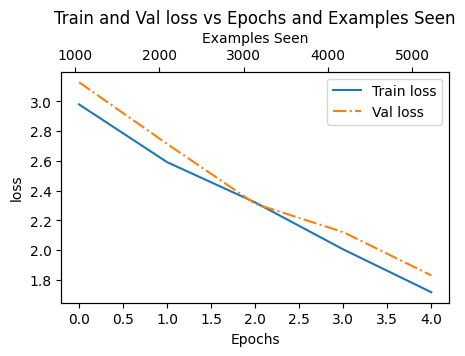

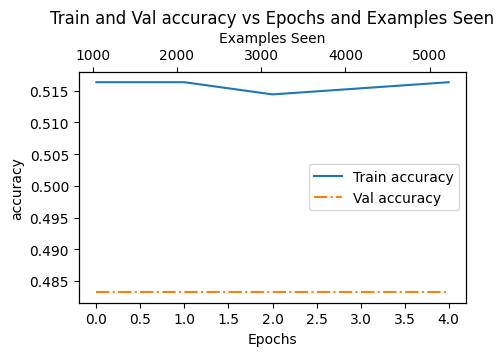

In [16]:
allowed_modules = ["out_head", "final_norm"]
file_path = "E:\AI_projects\LLMs\LLMs-from-scratch-mine\chapter5\gpt_124M_weights.pth"
model2 = get_model(GPT_CONFIG_124M, device="cuda", file_path=file_path, grid_allowed_modules=allowed_modules)
optimizer = torch.optim.AdamW(model2.parameters(), lr=1e-5, weight_decay=0.01)
model2.eval()
t_loss, val_loss = calculate_loss(train_loader, model2, device="cuda", num_batches=10), calculate_loss(val_loader, model2, device="cuda", num_batches=10)
print(f"Initial Train Loss: {t_loss:.4f}, Initial Val Loss: {val_loss:.4f}")

num_epochs = 5
val_freq = 1

train_losses, val_losses, train_accs, val_accs, examples_seen = train_loader_f(train_loader, val_loader, model2, optimizer, device="cuda", num_epochs=num_epochs, val_freq=val_freq)

plot_values(list(range(0, num_epochs, val_freq)), examples_seen, train_losses, val_losses, label='loss')
plot_values(list(range(0, num_epochs, val_freq)), examples_seen, train_accs, val_accs, label='accuracy')

C:\Users\86178\AppData\Local\Temp\ipykernel_20268\2615074366.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(file_path))


Unfrozen module: out_head
Unfrozen module: final_norm
Initial Train Loss: 4.4082, Initial Val Loss: 3.5700
Epoch 1/10 - Train Loss: 2.8064, Val Loss: 2.6442, Train Acc: 0.4817, Val Acc: 0.5168
Epoch 2/10 - Train Loss: 2.0941, Val Loss: 2.1319, Train Acc: 0.4837, Val Acc: 0.5168
Epoch 3/10 - Train Loss: 1.5498, Val Loss: 1.5011, Train Acc: 0.4846, Val Acc: 0.5168
Epoch 4/10 - Train Loss: 1.1062, Val Loss: 1.0720, Train Acc: 0.4846, Val Acc: 0.5168
Epoch 5/10 - Train Loss: 0.8922, Val Loss: 0.7741, Train Acc: 0.4846, Val Acc: 0.5168
Epoch 6/10 - Train Loss: 0.8285, Val Loss: 0.8089, Train Acc: 0.4856, Val Acc: 0.5168
Epoch 7/10 - Train Loss: 0.8623, Val Loss: 0.8259, Train Acc: 0.5000, Val Acc: 0.4362
Epoch 8/10 - Train Loss: 0.8556, Val Loss: 0.8435, Train Acc: 0.5106, Val Acc: 0.4832
Epoch 9/10 - Train Loss: 0.8069, Val Loss: 0.8632, Train Acc: 0.5125, Val Acc: 0.4832
Epoch 10/10 - Train Loss: 0.8187, Val Loss: 0.8133, Train Acc: 0.5115, Val Acc: 0.4832


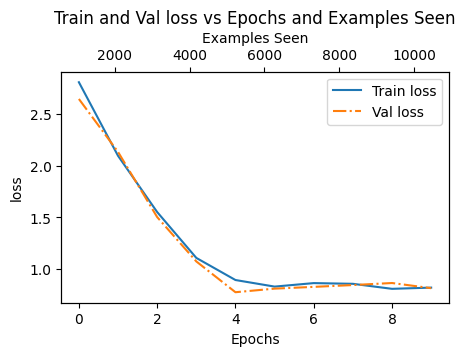

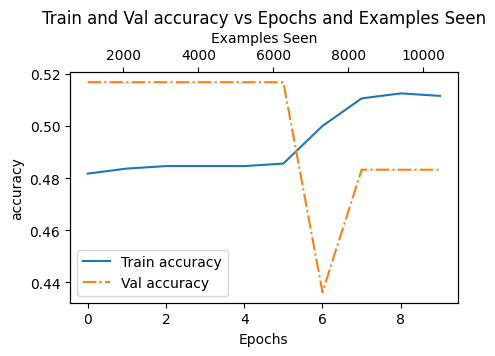

In [17]:
allowed_modules = ["out_head", "final_norm"]
file_path = "E:\AI_projects\LLMs\LLMs-from-scratch-mine\chapter5\gpt_124M_weights.pth"
model22 = get_model(GPT_CONFIG_124M, device="cuda", file_path=file_path, grid_allowed_modules=allowed_modules)
optimizer = torch.optim.AdamW(model22.parameters(), lr=2e-5, weight_decay=0.01)
model22.eval()
t_loss, val_loss = calculate_loss(train_loader, model22, device="cuda", num_batches=10), calculate_loss(val_loader, model22, device="cuda", num_batches=10)
print(f"Initial Train Loss: {t_loss:.4f}, Initial Val Loss: {val_loss:.4f}")

num_epochs = 10
val_freq = 1

train_losses, val_losses, train_accs, val_accs, examples_seen = train_loader_f(train_loader, val_loader, model22, optimizer, device="cuda", num_epochs=num_epochs, val_freq=val_freq)

plot_values(list(range(0, num_epochs, val_freq)), examples_seen, train_losses, val_losses, label='loss')
plot_values(list(range(0, num_epochs, val_freq)), examples_seen, train_accs, val_accs, label='accuracy')

C:\Users\86178\AppData\Local\Temp\ipykernel_20268\2615074366.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(file_path))


Unfrozen module: out_head
Unfrozen module: final_norm
Initial Train Loss: 0.7695, Initial Val Loss: 0.7528
Epoch 1/10 - Train Loss: 0.8243, Val Loss: 0.8814, Train Acc: 0.5135, Val Acc: 0.4832
Epoch 2/10 - Train Loss: 0.8206, Val Loss: 0.8321, Train Acc: 0.5135, Val Acc: 0.4832
Epoch 3/10 - Train Loss: 0.8277, Val Loss: 0.9382, Train Acc: 0.5144, Val Acc: 0.4832
Epoch 4/10 - Train Loss: 0.7912, Val Loss: 0.7735, Train Acc: 0.5125, Val Acc: 0.4832
Epoch 5/10 - Train Loss: 0.7930, Val Loss: 0.8170, Train Acc: 0.5144, Val Acc: 0.4832
Epoch 6/10 - Train Loss: 0.8485, Val Loss: 0.7981, Train Acc: 0.5125, Val Acc: 0.4832
Epoch 7/10 - Train Loss: 0.8028, Val Loss: 0.8114, Train Acc: 0.5115, Val Acc: 0.4832
Epoch 8/10 - Train Loss: 0.8326, Val Loss: 0.8069, Train Acc: 0.5115, Val Acc: 0.4832
Epoch 9/10 - Train Loss: 0.8118, Val Loss: 0.7383, Train Acc: 0.5144, Val Acc: 0.4832
Epoch 10/10 - Train Loss: 0.7828, Val Loss: 0.8396, Train Acc: 0.5135, Val Acc: 0.4832


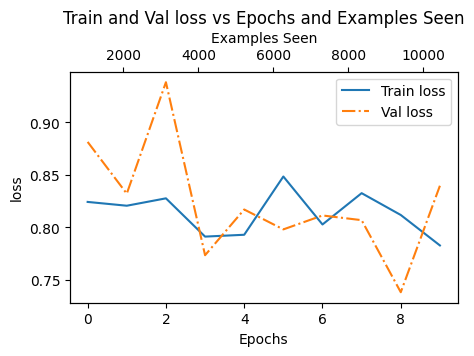

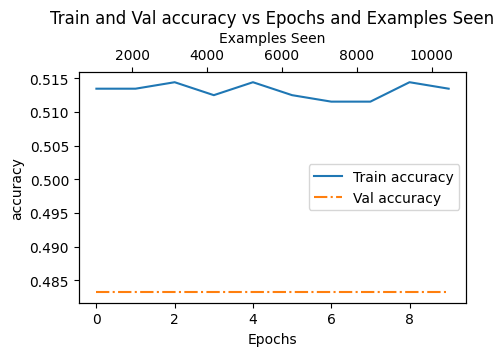

In [22]:
allowed_modules = ["out_head", "final_norm"]
file_path = "E:\AI_projects\LLMs\LLMs-from-scratch-mine\chapter5\gpt_124M_weights.pth"
model23 = get_model(GPT_CONFIG_124M, device="cuda", file_path=file_path, grid_allowed_modules=allowed_modules)
optimizer = torch.optim.AdamW(model23.parameters(), lr=2e-5, weight_decay=0.1)
model23.eval()
t_loss, val_loss = calculate_loss(train_loader, model23, device="cuda", num_batches=10), calculate_loss(val_loader, model23, device="cuda", num_batches=10)
print(f"Initial Train Loss: {t_loss:.4f}, Initial Val Loss: {val_loss:.4f}")

num_epochs = 10
val_freq = 1

train_losses, val_losses, train_accs, val_accs, examples_seen = train_loader_f(train_loader, val_loader, model22, optimizer, device="cuda", num_epochs=num_epochs, val_freq=val_freq)

plot_values(list(range(0, num_epochs, val_freq)), examples_seen, train_losses, val_losses, label='loss')
plot_values(list(range(0, num_epochs, val_freq)), examples_seen, train_accs, val_accs, label='accuracy')

## out_head & final_norm & blocks[-1]

In [ ]:


allowed_modules = ["out_head", "final_norm", "blocks[-1]"]
file_path = "E:\AI_projects\LLMs\LLMs-from-scratch-mine\chapter5\gpt_124M_weights.pth"
model3 = get_model(GPT_CONFIG_124M, device="cuda", file_path=file_path, grid_allowed_modules=allowed_modules)
optimizer = torch.optim.AdamW(model3.parameters(), lr=1e-5, weight_decay=0.01)
model3.eval()
t_loss, val_loss = calculate_loss(train_loader, model3, device="cuda", num_batches=10), calculate_loss(val_loader, model3, device="cuda", num_batches=10)
print(f"Initial Train Loss: {t_loss:.4f}, Initial Val Loss: {val_loss:.4f}")

num_epochs = 5
val_freq = 1

train_losses, val_losses, train_accs, val_accs, examples_seen = train_loader_f(train_loader, val_loader, model3, optimizer, device="cuda", num_epochs=num_epochs, val_freq=val_freq)

plot_values(list(range(0, num_epochs, val_freq)), examples_seen, train_losses, val_losses, label='loss')
plot_values(list(range(0, num_epochs, val_freq)), examples_seen, train_accs, val_accs, label='accuracy')

C:\Users\86178\AppData\Local\Temp\ipykernel_20268\2615074366.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(file_path))


Unfrozen module: out_head
Unfrozen module: final_norm
Unfrozen module: blocks[-1]
Initial Train Loss: 1.7452, Initial Val Loss: 1.8030
Epoch 1/5 - Train Loss: 0.7335, Val Loss: 0.7280, Train Acc: 0.7212, Val Acc: 0.7919
Epoch 2/5 - Train Loss: 0.6741, Val Loss: 0.6883, Train Acc: 0.5808, Val Acc: 0.6174
Epoch 3/5 - Train Loss: 0.6276, Val Loss: 0.6499, Train Acc: 0.6413, Val Acc: 0.6644
Epoch 4/5 - Train Loss: 0.5876, Val Loss: 0.5944, Train Acc: 0.6817, Val Acc: 0.7315
Epoch 5/5 - Train Loss: 0.5183, Val Loss: 0.5163, Train Acc: 0.7394, Val Acc: 0.7987


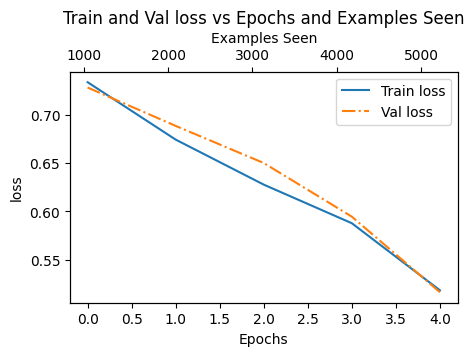

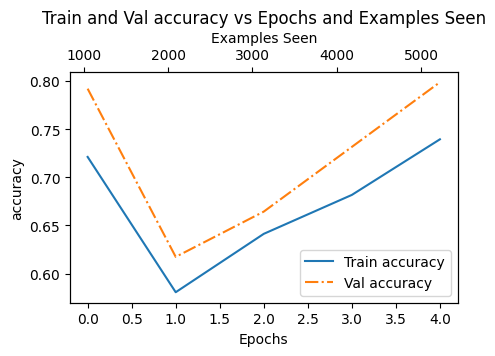

In [19]:
allowed_modules = ["out_head", "final_norm", "blocks[-1]"]
file_path = "E:\AI_projects\LLMs\LLMs-from-scratch-mine\chapter5\gpt_124M_weights.pth"
model32 = get_model(GPT_CONFIG_124M, device="cuda", file_path=file_path, grid_allowed_modules=allowed_modules)
optimizer = torch.optim.AdamW(model32.parameters(), lr=5e-5, weight_decay=0.01)
model32.eval()
t_loss, val_loss = calculate_loss(train_loader, model32, device="cuda", num_batches=10), calculate_loss(val_loader, model32, device="cuda", num_batches=10)
print(f"Initial Train Loss: {t_loss:.4f}, Initial Val Loss: {val_loss:.4f}")

num_epochs = 5
val_freq = 1

train_losses, val_losses, train_accs, val_accs, examples_seen = train_loader_f(train_loader, val_loader, model32, optimizer, device="cuda", num_epochs=num_epochs, val_freq=val_freq)

plot_values(list(range(0, num_epochs, val_freq)), examples_seen, train_losses, val_losses, label='loss')
plot_values(list(range(0, num_epochs, val_freq)), examples_seen, train_accs, val_accs, label='accuracy')

C:\Users\86178\AppData\Local\Temp\ipykernel_20268\2615074366.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(file_path))


Unfrozen module: out_head
Unfrozen module: final_norm
Unfrozen module: blocks[-1]
Initial Train Loss: 0.7293, Initial Val Loss: 0.7874
Epoch 1/5 - Train Loss: 0.7033, Val Loss: 0.6826, Train Acc: 0.8212, Val Acc: 0.7852
Epoch 2/5 - Train Loss: 0.5958, Val Loss: 0.5718, Train Acc: 0.7356, Val Acc: 0.7248
Epoch 3/5 - Train Loss: 0.4020, Val Loss: 0.4359, Train Acc: 0.9183, Val Acc: 0.8926
Epoch 4/5 - Train Loss: 0.1291, Val Loss: 0.1932, Train Acc: 0.9635, Val Acc: 0.9396
Epoch 5/5 - Train Loss: 0.0924, Val Loss: 0.1490, Train Acc: 0.9769, Val Acc: 0.9396


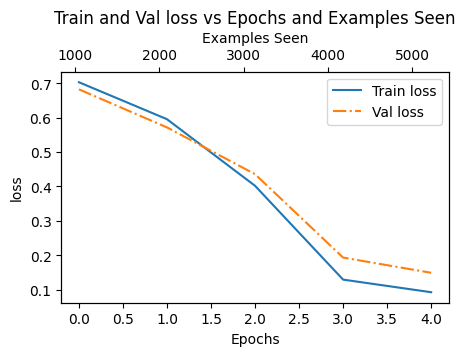

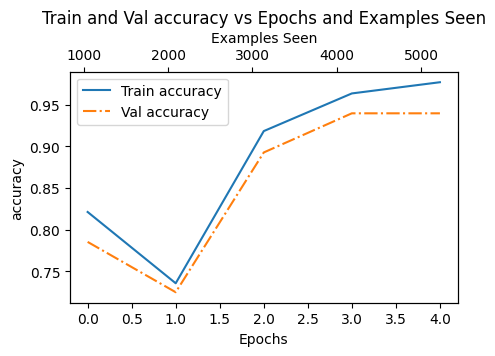

In [20]:
allowed_modules = ["out_head", "final_norm", "blocks[-1]"]
file_path = "E:\AI_projects\LLMs\LLMs-from-scratch-mine\chapter5\gpt_124M_weights.pth"
model32 = get_model(GPT_CONFIG_124M, device="cuda", file_path=file_path, grid_allowed_modules=allowed_modules)
optimizer = torch.optim.AdamW(model32.parameters(), lr=5e-5, weight_decay=0.1)
model32.eval()
t_loss, val_loss = calculate_loss(train_loader, model32, device="cuda", num_batches=10), calculate_loss(val_loader, model32, device="cuda", num_batches=10)
print(f"Initial Train Loss: {t_loss:.4f}, Initial Val Loss: {val_loss:.4f}")

num_epochs = 5
val_freq = 1

train_losses, val_losses, train_accs, val_accs, examples_seen = train_loader_f(train_loader, val_loader, model32, optimizer, device="cuda", num_epochs=num_epochs, val_freq=val_freq)

plot_values(list(range(0, num_epochs, val_freq)), examples_seen, train_losses, val_losses, label='loss')
plot_values(list(range(0, num_epochs, val_freq)), examples_seen, train_accs, val_accs, label='accuracy')